# Análisis de Datos para Ciberseguridad
### **Trabajo práctico 2**

**Ph. D. Saúl Calderón Ramírez**  
Instituto Tecnológico de Costa Rica  
Escuela de Ingeniería en Computación, Programa de Ciencias de Datos  
Pattern Recognition and MAchine Learning Group (PARMA-Group)

| Daniel Araya | Andrés Mora | Alvaro |
| :--             | :--         | :--                    |
| *Carnet: 2025800352* | *Carnet: 2013241401* | *Carnet: **XXXXXXXXXX*** |


# Imports and data loading

In [5]:
!pip install tensorflow

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
#tomado de https://www.kaggle.com/code/wailinnoo/intrusion-detection-system-using-kdd99-dataset
import pandas as pd
from tensorflow.keras.utils import get_file

try:
    path = get_file('kddcup.data_10_percent.gz', origin='http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz')
except:
    print('Error downloading')
    raise

print(path)

# This file is a CSV, just no CSV extension or headers
# Download from: http://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html
pd_data_frame = pd.read_csv(path, header=None)

# The CSV file has no column heads, so add them
pd_data_frame.columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'outcome'
]

#describe the dataset
#transform nominal features using a one hot vector encoding
pd_data_frame.describe()




2144903/2144903 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/root/.keras/datasets/kddcup.data_10_percent.gz


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494021.000000,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,...,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,47.979302,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148247,0.010212,...,232.470778,188.665670,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.746472,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355345,1.798326,...,64.745380,106.040437,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Preprocessing and  Dummy encoding transformation

Attacks fall into four main categories:






1.   DOS: denial-of-service, e.g. syn flood;
2.   R2L: unauthorized access from a remote machine, e.g. guessing password;

3. U2R:  unauthorized access to local superuser (root) privileges, e.g., various ``buffer overflow'' attacks;

4. probing: surveillance and other probing, e.g., port scanning.


It is important to note that the test data is not from the same probability distribution as the training data, and it includes specific attack types not in the training data.  This makes the task more realistic.  Some intrusion experts believe that most novel attacks are variants of known attacks and the "signature" of known attacks can be sufficient to catch novel variants.  The datasets contain a total of 24 training attack types, with an additional 14 types in the test data only.

Neptune is the most frequent attack in the dataset, consisting in a type of denial-of-service (DoS) attack overwhelming systems with SYN requests (synchronize request, is a type of network packet used in the TCP handshake to initiate a connection between a client and a server).

**In this work we will focus in the detection of backdrop attacks**.

In [8]:
# For now, just drop NA's (rows with missing values), in case there are
pd_data_frame.dropna(inplace=True,axis=1)

# Checkng for DUPLICATE values
pd_data_frame.drop_duplicates(keep='first', inplace = True)
print(pd_data_frame.describe())
filtered_df = pd_data_frame


            duration     src_bytes     dst_bytes           land  \
count  145586.000000  1.455860e+05  1.455860e+05  145586.000000   
mean      132.025181  7.995700e+03  2.859780e+03       0.000137   
std      1224.157053  1.820383e+06  6.080979e+04       0.011720   
min         0.000000  0.000000e+00  0.000000e+00       0.000000   
25%         0.000000  0.000000e+00  0.000000e+00       0.000000   
50%         0.000000  1.470000e+02  1.050000e+02       0.000000   
75%         0.000000  2.880000e+02  1.164750e+03       0.000000   
max     58329.000000  6.933756e+08  5.155468e+06       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   145586.000000  145586.000000  145586.000000      145586.000000   
mean         0.020201       0.000048       0.100174           0.000515   
std          0.239368       0.010150       1.426798           0.028585   
min          0.000000       0.000000       0.000000           0.000000   
25%          0.000000     

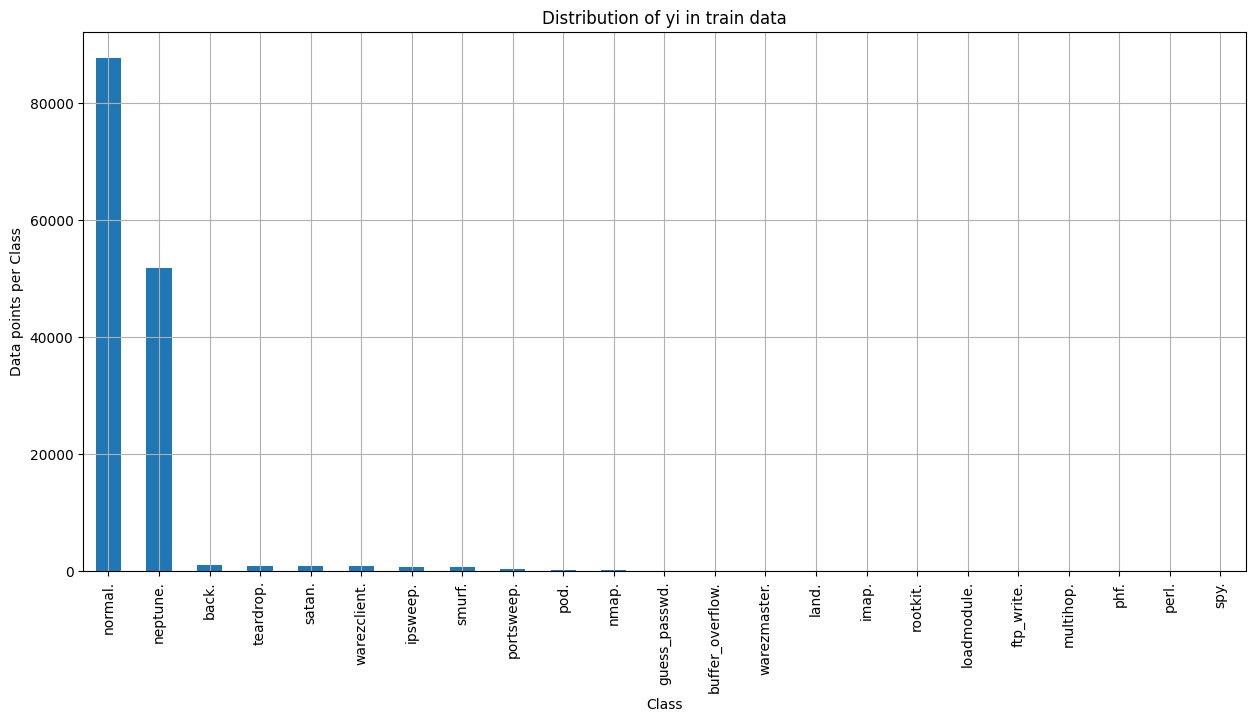

In [9]:
# distribution of the attack categories (outcome)
# Exploratory data analysis
import matplotlib.pyplot as plt
from matplotlib.pyplot import *

plt.figure(figsize=(15,7))
class_distribution = pd_data_frame['outcome'].value_counts()
class_distribution.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Data points per Class')
plt.title('Distribution of yi in train data')
plt.grid()
plt.show()

#normal and neptune are the more prominent classes

In [10]:
list_nominal_features = ["flag", "protocol_type", "service"]

# Apply one-hot encoding to the nominal features
df_encoded = pd.get_dummies(filtered_df, columns=list_nominal_features)

# Convert boolean columns (from one-hot encoding) to integers (0 or 1) in df_encoded
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

# Display the first few rows of the modified DataFrame to verify
print("DataFrame with boolean columns converted to integers:")
display(df_encoded.describe())
print("Columns after nominal attributes encoded: ")
for i in df_encoded.columns:
  print(i)


DataFrame with boolean columns converted to integers:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois
count,145586.000000,1.455860e+05,1.455860e+05,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,...,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000,145586.000000
mean,132.025181,7.995700e+03,2.859780e+03,0.000137,0.020201,0.000048,0.100174,0.000515,0.491490,0.026177,...,0.003517,0.000007,0.000034,0.000955,0.000096,0.003043,0.000721,0.000728,0.000728,0.000756
std,1224.157053,1.820383e+06,6.080979e+04,0.011720,0.239368,0.010150,1.426798,0.028585,0.499929,3.311373,...,0.059199,0.002621,0.005860,0.030885,0.009806,0.055078,0.026846,0.026973,0.026973,0.027477
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.470000e+02,1.050000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.880000e+02,1.164750e+03,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Columns after nominal attributes encoded: 
duration
src_bytes
dst_bytes
land
wrong_fragment
urgent
hot
num_failed_logins
logged_in
num_compromised
root_shell
su_attempted
num_root
num_file_creations
num_shells
num_access_files
num_outbound_cmds
is_host_login
is_guest_login
count
srv_count
serror_rate
srv_serror_rate
rerror_rate
srv_rerror_rate
same_srv_rate
diff_srv_rate
srv_diff_host_rate
dst_host_count
dst_host_srv_count
dst_host_same_srv_rate
dst_host_diff_srv_rate
dst_host_same_src_port_rate
dst_host_srv_diff_host_rate
dst_host_serror_rate
dst_host_srv_serror_rate
dst_host_rerror_rate
dst_host_srv_rerror_rate
outcome
flag_OTH
flag_REJ
flag_RSTO
flag_RSTOS0
flag_RSTR
flag_S0
flag_S1
flag_S2
flag_S3
flag_SF
flag_SH
protocol_type_icmp
protocol_type_tcp
protocol_type_udp
service_IRC
service_X11
service_Z39_50
service_auth
service_bgp
service_courier
service_csnet_ns
service_ctf
service_daytime
service_discard
service_domain
service_domain_u
service_echo
service_eco_i
service_ecr_i
serv

## Split data


Split the `pd_data_frame` into training, validation, and test sets using `train_test_split` from `sklearn.model_selection`.

In [11]:

from sklearn.preprocessing import LabelEncoder

# create the label codifier
label_encoder = LabelEncoder()



# Aplicar el codificador a la columna 'outcome'
df_encoded['outcome'] = label_encoder.fit_transform(df_encoded['outcome'])


y = df_encoded['outcome'].values.astype('float')
print(" y ", y[0])
x_columns = df_encoded.columns.drop(['outcome'])
x = df_encoded[x_columns].values.astype('float')

 y  11.0


In [12]:
from sklearn.model_selection import train_test_split
#split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Standardize the data (relevant for neural networks)
Ensure that all the variables have mu = 0 and sigma = 1

In [13]:
from sklearn.preprocessing import StandardScaler



# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
x_train_scaled = scaler.fit_transform(x_train)

# Transform the test data using the fitted scaler
x_test_scaled = scaler.transform(x_test)

## 1. (30 puntos) Implementacion de un *`árbol`* de decision y random forests para clasificar todos los tipos de ataques (scikit learn)

### 1. Genere una función split_dataset la cual divida los datos en  entrenamiento (70 %), validación (15 %) y prueba (15 %).

1.   List item
2.   List item



In [14]:
from typing import Tuple
import numpy as np
from sklearn.model_selection import train_test_split

def split_dataset(
    X,
    y,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    stratify: bool = True,
    random_state: int = 42
) -> Tuple:
    """
    Divide X, y en train/val/test con proporciones dadas.
    - Mantiene la distribución de clases (stratify=True).
    - Hace split en dos pasos: (train+val) vs test, y luego train vs val.
    """
    total = train_size + val_size + test_size
    if not np.isclose(total, 1.0):
        raise ValueError("train_size + val_size + test_size debe sumar 1.0")

    strat_all = y if stratify else None

    # 1) Separamos test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=strat_all,
        shuffle=True,
        random_state=random_state
    )

    # 2) De lo restante, sacamos validación
    val_rel = val_size / (train_size + val_size)  # proporción relativa dentro de X_temp
    strat_temp = y_temp if stratify else None

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_rel,
        stratify=strat_temp,
        shuffle=True,
        random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


In [15]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(x, y, random_state=42) # Use x and y from previous steps

n = len(y)
print({
    "train": (len(y_train), len(y_train)/n),
    "val":   (len(y_val),   len(y_val)/n),
    "test":  (len(y_test),  len(y_test)/n),
})


{'train': (101910, 0.6999986262415342), 'val': (21838, 0.1500006868792329), 'test': (21838, 0.1500006868792329)}


In [16]:
from sklearn.preprocessing import StandardScaler

def standardize_by_train(X_train, X_val, X_test, with_mean=True, with_std=True):
    """
    Ajusta StandardScaler SOLO con X_train y transforma X_train, X_val y X_test.
    Devuelve: X_train_scaled, X_val_scaled, X_test_scaled, scaler
    """
    scaler = StandardScaler(with_mean=with_mean, with_std=with_std)
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)
    return X_train_s, X_val_s, X_test_s, scaler

# Usando los splits que ya generaste con split_dataset(...)
X_train_scaled, X_val_scaled, X_test_scaled, scaler = standardize_by_train(
    X_train, X_val, X_test
)


### 2. (15 puntos) Entrene un arbol de decision (de scikitlearn) para clasificar los ataques en todas las categorias originales del dataset:

#### a) Optimice la profundidad máxima, cantidad mínima de observaciones por partición y el criterio de pureza usando optuna o weights and biases. Documente los rangos de cada hiper-parametro y justifique la decisión por cada uno. Muestre los gráficos de ese proceso de optimización y seleccione las 3 mejores arquitecturas.

In [17]:
%pip install -q optuna

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
import optuna

seed = 42
np.random.seed(seed)

def macro_fpr(y_true, y_pred):
    """
    Tasa de falsos positivos macro-promediada.
    """
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    FP = cm.sum(axis=0) - np.diag(cm)
    TN = cm.sum() - (cm.sum(axis=1) + cm.sum(axis=0) - np.diag(cm))
    return np.mean(FP / (FP + TN + 1e-12))


In [19]:
# ----- Objetivo de Optuna: maximizar F1-macro en VALIDACIÓN -----
def objective(trial):
    max_depth = trial.suggest_categorical("max_depth", [None] + list(range(3, 41)))
    min_samples_split = trial.suggest_int("min_samples_split", 2, 64)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=seed
    )
    # Usamos splits de entrenamiento/validación NO escalados
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    return f1_score(y_val, y_pred, average="macro")

# ----- Estudio Optuna con TPE sembrado (reproducible) -----
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)  # ajusta n_trials si lo necesitas

[I 2025-09-14 00:10:08,837] A new study created in memory with name: no-name-6c74fa69-64aa-4c4c-b988-93f61019cb08


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-09-14 00:10:10,677] Trial 0 finished with value: 0.6742408017302508 and parameters: {'max_depth': 13, 'min_samples_split': 29, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6742408017302508.
[I 2025-09-14 00:10:15,250] Trial 1 finished with value: 0.682984620922139 and parameters: {'max_depth': 29, 'min_samples_split': 41, 'criterion': 'gini'}. Best is trial 1 with value: 0.682984620922139.
[I 2025-09-14 00:10:17,577] Trial 2 finished with value: 0.680126886322745 and parameters: {'max_depth': 30, 'min_samples_split': 8, 'criterion': 'entropy'}. Best is trial 1 with value: 0.682984620922139.
[I 2025-09-14 00:10:23,637] Trial 3 finished with value: 0.6524188266285386 and parameters: {'max_depth': 30, 'min_samples_split': 54, 'criterion': 'gini'}. Best is trial 1 with value: 0.682984620922139.
[I 2025-09-14 00:10:26,491] Trial 4 finished with value: 0.6835676658803403 and parameters: {'max_depth': 12, 'min_samples_split': 43, 'criterion': 'entropy'}. Best is trial 4 with

/tmp/ipython-input-558640039.py:8: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = plot_optimization_history(study); plt.tight_layout(); plt.show()


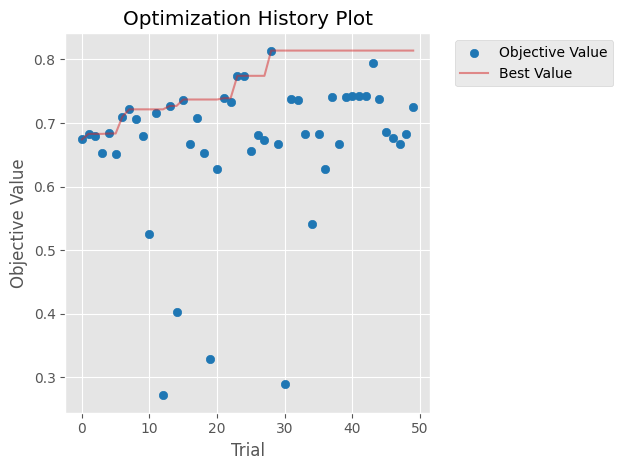

/tmp/ipython-input-558640039.py:9: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = plot_param_importances(study);    plt.tight_layout(); plt.show()


KeyboardInterrupt: 

In [20]:
# ----- Gráficas del proceso (matplotlib backend) -----
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice
)

fig1 = plot_optimization_history(study); plt.tight_layout(); plt.show()
fig2 = plot_param_importances(study);    plt.tight_layout(); plt.show()
fig3 = plot_slice(study);                plt.tight_layout(); plt.show()

# ----- Tabla ordenada de trials (para el informe) -----
trials = [
    {
        "trial_number": t.number,
        "value_f1_val": t.value,
        **t.params
    }
    for t in study.trials if t.value is not None
]
df_trials = pd.DataFrame(trials).sort_values("value_f1_val", ascending=False)
display(df_trials.head(10))  # opcional: ver los 10 mejores

# ----- Top-3 mejores configuraciones -----
top3 = df_trials.head(3).reset_index(drop=True)
display(top3)

top3_params = [
    row.drop(labels=["trial_number", "value_f1_val"]).to_dict()
    for _, row in top3.iterrows()
]

In [21]:
import pandas as pd
def _concat(a, b):
    return pd.concat([a,b], axis=0) if hasattr(a, "iloc") else np.concatenate([a,b], axis=0)

sorted_trials = sorted([t for t in study.trials if t.value is not None], key=lambda t: t.value, reverse=True)[:3]
top3_params = [t.params for t in sorted_trials]

results = []
X_tr = _concat(X_train, X_val)
y_tr = _concat(y_train, y_val)

for i, params in enumerate(top3_params, 1):
    clf = DecisionTreeClassifier(**params, random_state=seed)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_test)
    results.append({
        "rank": i,
        "params": params,
        "acc": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "fpr_macro": macro_fpr(y_test, y_pred)
    })

pd.DataFrame(results)


,rank,params,acc,f1_macro,fpr_macro
0,1,"{'max_depth': 17, 'min_samples_split': 6, 'cri...",0.998672,0.746760,0.000124
1,2,"{'max_depth': 22, 'min_samples_split': 7, 'cri...",0.998718,0.741323,0.000110
2,3,"{'max_depth': 21, 'min_samples_split': 8, 'cri...",0.998672,0.668289,0.000110


### Justificación de rangos de hiperparámetros (Decision Tree + Optuna)

- **`max_depth`** ∈ {None} ∪ [3, 40]:  
  Se exploran árboles desde muy superficiales hasta profundos. Incluir `None` permite crecer hasta pureza, capturando interacciones complejas (riesgo de sobreajuste). El rango 3–40 busca un compromiso entre capacidad y generalización dada la alta cardinalidad tras el one-hot (e.g., `service`, `protocol_type`, `flag`) y el desbalance de clases de KDD’99.

- **`min_samples_split`** ∈ [2, 64]:  
  Controla la granularidad y actúa como regularizador. Valores mayores (p.ej., ≥16, ≥32) ayudan a evitar splits espurios sobre ruido y estabilizan el árbol en datasets grandes/desbalanceados; el límite 64 ofrece poda efectiva sin forzar infra-ajuste.

- **`criterion`** ∈ {`gini`, `entropy`}:  
  Ambas medidas son estándar. Dado que el objetivo es **F1-macro** (sensibilidad a clases minoritarias), se deja a Optuna decidir qué criterio favorece mejor el equilibrio entre clases.


#### b) Compare las tres mejores arquitecturas, para al menos 10 corridas diferentes (particiones), el F1-score promedio para todas las clases y la tasa de falsos positivos promedio para todas las clases, presen- te medias y desviaciones estandar usando la particion de prueba. Comente los resultados.

In [22]:
# =========================
# 2.b) Comparación top-3 con ≥10 corridas
# =========================
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
# macro_fpr(y_true, y_pred) ya definida arriba

# --- (opcional) Rescate de top3_params si no existe, a partir del 'study' ---
if 'top3_params' not in globals():
    trials = [
        {"trial_number": t.number, "value_f1_val": t.value, **t.params}
        for t in study.trials if t.value is not None
    ]
    df_trials = pd.DataFrame(trials).sort_values("value_f1_val", ascending=False)
    top3 = df_trials.head(3).reset_index(drop=True)
    top3_params = [
        row.drop(labels=["trial_number", "value_f1_val"]).to_dict()
        for _, row in top3.iterrows()
    ]

# --- Evaluación: 10 particiones por cada una de las top-3 configuraciones ---
summary_rows = []
all_runs_rows = []

num_runs = 10
partition_seeds = list(range(num_runs))  # 0..9; ajusta si quieres otras semillas

for m_idx, params in enumerate(top3_params, start=1):
    f1_scores = []
    fpr_scores = []

    for i, rs in enumerate(partition_seeds):
        # Nueva partición (70/15/15 estratificada) en cada corrida
        X_train_run, X_val_run, X_test_run, y_train_run, y_val_run, y_test_run = split_dataset(x, y, random_state=rs)

        # Entrenamos en TRAIN+VAL (como pide el punto, comparar arquitecturas ya “fijadas”)
        X_train_full = np.concatenate([X_train_run, X_val_run], axis=0)
        y_train_full = np.concatenate([y_train_run, y_val_run], axis=0)

        clf = DecisionTreeClassifier(**params, random_state=rs)  # random_state por consistencia
        clf.fit(X_train_full, y_train_full)

        y_pred_test = clf.predict(X_test_run)

        f1  = f1_score(y_test_run, y_pred_test, average="macro")
        fpr = macro_fpr(y_test_run, y_pred_test)

        f1_scores.append(f1)
        fpr_scores.append(fpr)

        # Guarda fila de la corrida (útil para boxplots por modelo)
        all_runs_rows.append({
            "model_rank": m_idx,
            "run": i + 1,
            "max_depth": params.get("max_depth", None),
            "min_samples_split": params.get("min_samples_split", None),
            "criterion": params.get("criterion", None),
            "f1_macro": f1,
            "fpr_macro": fpr
        })

    # Resumen por modelo (medias y desviaciones)
    summary_rows.append({
        "model_rank": m_idx,
        "max_depth": params.get("max_depth", None),
        "min_samples_split": params.get("min_samples_split", None),
        "criterion": params.get("criterion", None),
        "f1_macro_mean": np.mean(f1_scores),
        "f1_macro_std":  np.std(f1_scores),
        "fpr_macro_mean": np.mean(fpr_scores),
        "fpr_macro_std":  np.std(fpr_scores),
    })

df_runs = pd.DataFrame(all_runs_rows)     # una fila por corrida
df_summary = pd.DataFrame(summary_rows)   # resumen por modelo (top-3)

# Ordena por desempeño principal (F1 macro)
df_summary = df_summary.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

display(df_summary)
display(df_runs.head())


,model_rank,max_depth,min_samples_split,criterion,f1_macro_mean,f1_macro_std,fpr_macro_mean,fpr_macro_std
0,1,17,6,gini,0.769046,0.034144,0.000124,0.000026
1,3,21,8,gini,0.754101,0.028671,0.000119,0.000025
2,2,22,7,gini,0.748737,0.037939,0.000113,0.000024


,model_rank,run,max_depth,min_samples_split,criterion,f1_macro,fpr_macro
0,1,1,17,6,gini,0.817233,0.000161
1,1,2,17,6,gini,0.768341,0.000105
2,1,3,17,6,gini,0.784906,0.000105
3,1,4,17,6,gini,0.699827,0.000109
4,1,5,17,6,gini,0.738625,0.000149


### 3. (15 puntos) Usando tambien la libreria scikit learn entrene un random forest.

#### a) Optimice con optuna o weights and biases la cantidad de arboles del random forest . Defina el rango de numero de arboles de decision de forma justificada.

[I 2025-09-14 00:53:32,894] A new study created in memory with name: no-name-f891d71c-e92f-4ff1-af1b-207989e1be71


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-09-14 00:54:11,422] Trial 0 finished with value: 0.7689927392674156 and parameters: {'n_estimators': 325}. Best is trial 0 with value: 0.7689927392674156.
[I 2025-09-14 00:55:45,007] Trial 1 finished with value: 0.7689927392674156 and parameters: {'n_estimators': 775}. Best is trial 0 with value: 0.7689927392674156.
[I 2025-09-14 00:56:57,547] Trial 2 finished with value: 0.7689927392674156 and parameters: {'n_estimators': 600}. Best is trial 0 with value: 0.7689927392674156.
[I 2025-09-14 00:57:57,250] Trial 3 finished with value: 0.7689927392674156 and parameters: {'n_estimators': 500}. Best is trial 0 with value: 0.7689927392674156.
[I 2025-09-14 00:58:16,283] Trial 4 finished with value: 0.767760545002879 and parameters: {'n_estimators': 150}. Best is trial 0 with value: 0.7689927392674156.
[I 2025-09-14 00:58:33,881] Trial 5 finished with value: 0.767760545002879 and parameters: {'n_estimators': 150}. Best is trial 0 with value: 0.7689927392674156.
[I 2025-09-14 00:58:43,3

/tmp/ipython-input-1854852264.py:51: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = plot_optimization_history(study_rf); plt.tight_layout(); plt.show()


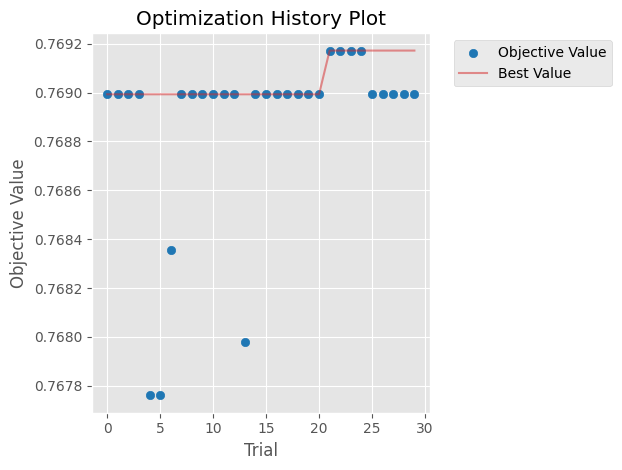

/tmp/ipython-input-1854852264.py:52: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = plot_param_importances(study_rf);    plt.tight_layout(); plt.show()


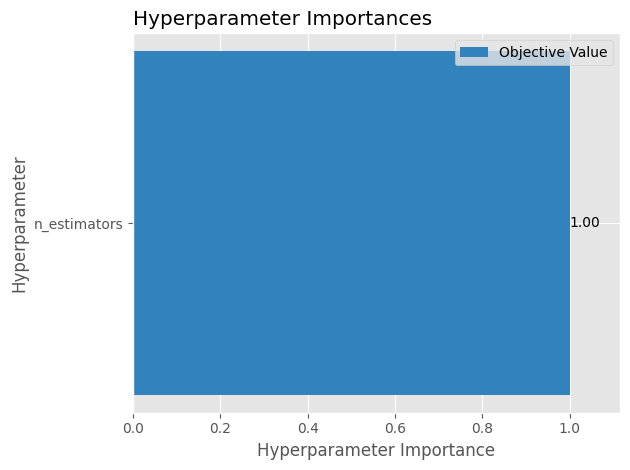

/tmp/ipython-input-1854852264.py:53: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig3 = plot_slice(study_rf);                plt.tight_layout(); plt.show()


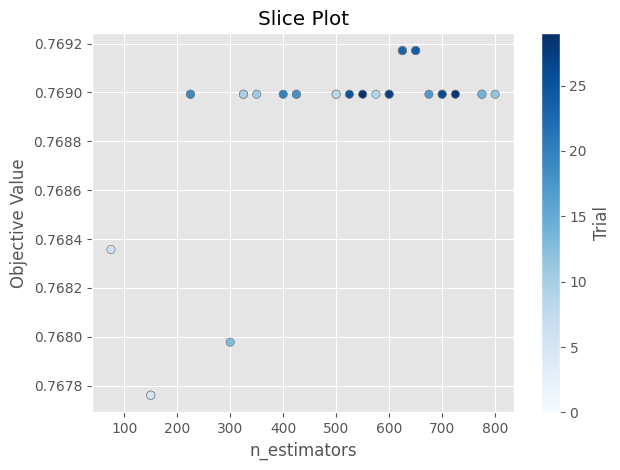

,trial_number,f1_val,n_estimators
24,24,0.769172,650
21,21,0.769172,625
22,22,0.769172,650
23,23,0.769172,625
0,0,0.768993,325
1,1,0.768993,775
12,12,0.768993,800
11,11,0.768993,350
9,9,0.768993,575
10,10,0.768993,325


,trial_number,f1_val,n_estimators
0,24,0.769172,650
1,21,0.769172,625


Best RF params (val): {'n_estimators': 625}
Test F1-macro (best on val): 0.759214389573794


In [24]:
# =========================
# 3.a) Optuna - Random Forest (tuning de n_estimators)
# =========================
# Requisitos:
# - X_train, X_val, X_test, y_train, y_val, y_test ya definidos con split_dataset(...)
# - macro_fpr(y_true, y_pred) ya definida (si no, define una versión como en 2.a)

%pip install -q optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import optuna

seed = 42
np.random.seed(seed)

# ----- Objetivo: maximizar F1-macro en VALIDACIÓN ajustando solo n_estimators -----
def objective_rf(trial):
    # Rango propuesto y justificado (ver markdown más abajo)
    n_estimators = trial.suggest_int("n_estimators", 50, 800, step=25)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=seed,
        n_jobs=-1,            # paraleliza para acelerar
        bootstrap=True,       # default
        max_depth=None,       # mantener otros hp por defecto (solo pedimos n_estimators)
        criterion="gini"      # default; no lo optimizamos en 3.a
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    return f1_score(y_val, y_pred, average="macro")

# ----- Estudio Optuna con TPE sembrado (reproducible) -----
study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)  # ajusta n_trials si necesitas

# ----- Gráficas del proceso -----
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice
)
fig1 = plot_optimization_history(study_rf); plt.tight_layout(); plt.show()
fig2 = plot_param_importances(study_rf);    plt.tight_layout(); plt.show()
fig3 = plot_slice(study_rf);                plt.tight_layout(); plt.show()

# ----- Tabla de trials ordenada por F1-macro (validación) -----
trials_rf = [
    {"trial_number": t.number, "f1_val": t.value, **t.params}
    for t in study_rf.trials if t.value is not None
]
df_trials_rf = pd.DataFrame(trials_rf).sort_values("f1_val", ascending=False)
display(df_trials_rf.head(10))

# ----- Selección de los 2 mejores n_estimators (pensando en el 3.b) -----
top2_rf = df_trials_rf.head(2).reset_index(drop=True)
display(top2_rf)
top2_rf_params = [ {"n_estimators": int(row["n_estimators"])} for _, row in top2_rf.iterrows() ]

# ----- (Opcional) Reentrenar el mejor en TRAIN+VAL y evaluar en TEST, solo como referencia de 3.a -----
best_rf_params = study_rf.best_params
clf_best_rf = RandomForestClassifier(
    **best_rf_params, random_state=seed, n_jobs=-1, bootstrap=True, max_depth=None, criterion="gini"
)
X_tr_rf = np.concatenate([X_train, X_val], axis=0)
y_tr_rf = np.concatenate([y_train, y_val], axis=0)
clf_best_rf.fit(X_tr_rf, y_tr_rf)
y_pred_test_rf = clf_best_rf.predict(X_test)

print("Best RF params (val):", best_rf_params)
print("Test F1-macro (best on val):", f1_score(y_test, y_pred_test_rf, average="macro"))

### Justificación del rango de `n_estimators` (Random Forest)

- **Inferior (50):** por debajo de ~50 árboles, la varianza del ensamble suele ser alta y la estabilidad entre particiones disminuye. 50 ofrece un punto de partida razonable y acorta el tiempo de búsqueda inicial.
- **Superior (800):** el error OOB/validación en Random Forest típicamente **satura** entre ~200–500 árboles en datasets tabulares grandes. Más árboles mejoran marginalmente (ley de rendimientos decrecientes) pero **escala linealmente el costo**. Con KDD’99 (10% set con cientos de miles de muestras) 800 fija un techo que permite capturar el posible *plateau* sin hacer el tuning prohibitivo.
- **Paso (25):** balancea granularidad y costo computacional. Diferencias menores a ~25 árboles rara vez cambian F1-macro de forma significativa frente al ruido de la partición, pero multiplican ensayos.

> Nota: se mantiene el resto de hiperparámetros por defecto porque el **punto 3.a** exige **optimizar solamente** `n_estimators`. En 3.b compararemos las **dos mejores** configuraciones con ≥10 corridas, reportando medias y DE de F1-macro y FPR-macro.


#### b) Compare los 2 mejores random forests seleccionados por la herramienta, haciendo 10 corridas diferentes (particiones), el F1-score promedio para todas las clases y la tasa de falsos positivos promedio para todas las clases, presente medias y desviaciones estandar usando la particion de prueba. Comente los resultados

In [25]:
# =========================
# 3.b) Comparación top-2 Random Forest con ≥10 corridas
# =========================
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# --- Recuperar top-2 si no está en memoria ---
if 'top2_rf_params' not in globals():
    if 'study_rf' in globals():
        trials_rf = [
            {"trial_number": t.number, "f1_val": t.value, **t.params}
            for t in study_rf.trials if t.value is not None
        ]
        df_trials_rf = pd.DataFrame(trials_rf).sort_values("f1_val", ascending=False)
        top2_rf = df_trials_rf.head(2).reset_index(drop=True)
        top2_rf_params = [{"n_estimators": int(row["n_estimators"])} for _, row in top2_rf.iterrows()]
    else:
        raise RuntimeError("No se encuentran top2_rf_params ni study_rf. Ejecuta 3.a primero.")

num_runs = 10
seeds = list(range(num_runs))

summary_rows = []
runs_rows = []

for m_idx, p in enumerate(top2_rf_params, start=1):
    n_est = int(p["n_estimators"])
    f1s, fprs = [], []

    for run_i, rs in enumerate(seeds, start=1):
        # Nueva partición (70/15/15 estratificada) en cada corrida
        X_train_run, X_val_run, X_test_run, y_train_run, y_val_run, y_test_run = split_dataset(x, y, random_state=rs)

        # Entrenamiento en TRAIN+VAL (como en 2.b)
        X_train_full = np.concatenate([X_train_run, X_val_run], axis=0)
        y_train_full = np.concatenate([y_train_run, y_val_run], axis=0)

        clf = RandomForestClassifier(
            n_estimators=n_est,
            random_state=rs,
            n_jobs=-1,
            bootstrap=True,
            max_depth=None,
            criterion="gini"
        )
        clf.fit(X_train_full, y_train_full)
        y_pred = clf.predict(X_test_run)

        f1  = f1_score(y_test_run, y_pred, average="macro")
        fpr = macro_fpr(y_test_run, y_pred)

        f1s.append(f1)
        fprs.append(fpr)

        runs_rows.append({
            "model_rank": m_idx,
            "run": run_i,
            "n_estimators": n_est,
            "f1_macro": f1,
            "fpr_macro": fpr
        })

    summary_rows.append({
        "model_rank": m_idx,
        "n_estimators": n_est,
        "f1_macro_mean": float(np.mean(f1s)),
        "f1_macro_std":  float(np.std(f1s)),
        "fpr_macro_mean": float(np.mean(fprs)),
        "fpr_macro_std":  float(np.std(fprs))
    })

df_runs_rf = pd.DataFrame(runs_rows)
df_summary_rf = pd.DataFrame(summary_rows).sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

display(df_summary_rf)   # tabla de medias y DE por modelo (para el PDF)
display(df_runs_rf.head())  # primeras filas por corrida (opcional)

# -------- Comentario automático para copiar al informe --------
best  = df_summary_rf.iloc[0]
second = df_summary_rf.iloc[1]

def pct(a, b):
    return 0.0 if b == 0 else 100.0 * (a - b) / b

delta_f1 = best["f1_macro_mean"] - second["f1_macro_mean"]
delta_f1_pct = pct(best["f1_macro_mean"], second["f1_macro_mean"])
delta_fpr = best["fpr_macro_mean"] - second["fpr_macro_mean"]
delta_fpr_pct = pct(best["fpr_macro_mean"], second["fpr_macro_mean"])

print("\n--- Comentario automático (3.b) ---")
print(f"Mejor RF: n_estimators={int(best['n_estimators'])} "
      f"→ F1-macro={best['f1_macro_mean']:.4f}±{best['f1_macro_std']:.4f}, "
      f"FPR-macro={best['fpr_macro_mean']:.6f}±{best['fpr_macro_std']:.6f}")
print(f"Segundo:  n_estimators={int(second['n_estimators'])} "
      f"→ F1-macro={second['f1_macro_mean']:.4f}±{second['f1_macro_std']:.4f}, "
      f"FPR-macro={second['fpr_macro_mean']:.6f}±{second['fpr_macro_std']:.6f}")

sig_hint = "no muestra una ventaja clara (|ΔF1| < 1×DE combinada)" \
           if abs(delta_f1) < (best['f1_macro_std'] + second['f1_macro_std'])/2 \
           else "muestra una ventaja consistente"

print(f"\nDiferencia: ΔF1={delta_f1:+.4f} ({delta_f1_pct:+.2f}%), "
      f"ΔFPR={delta_fpr:+.6f} ({delta_fpr_pct:+.2f}%).")
print(f"Interpretación: El modelo con {int(best['n_estimators'])} árboles {sig_hint}. "
      "Si la ganancia en F1 viene con FPR similar o menor, es preferible. "
      "Si F1 sube pero FPR aumenta de forma apreciable, considerar el trade-off según la aplicación.")


,model_rank,n_estimators,f1_macro_mean,f1_macro_std,fpr_macro_mean,fpr_macro_std
0,2,625,0.779887,0.040974,0.000075,0.000019
1,1,650,0.779862,0.041023,0.000075,0.000019


,model_rank,run,n_estimators,f1_macro,fpr_macro
0,1,1,650,0.771044,0.000085
1,1,2,650,0.836155,0.000055
2,1,3,650,0.741529,0.000067
3,1,4,650,0.758039,0.000087
4,1,5,650,0.698786,0.000096



--- Comentario automático (3.b) ---
Mejor RF: n_estimators=625 → F1-macro=0.7799±0.0410, FPR-macro=0.000075±0.000019
Segundo:  n_estimators=650 → F1-macro=0.7799±0.0410, FPR-macro=0.000075±0.000019

Diferencia: ΔF1=+0.0000 (+0.00%), ΔFPR=-0.000001 (-0.73%).
Interpretación: El modelo con 625 árboles no muestra una ventaja clara (|ΔF1| < 1×DE combinada). Si la ganancia en F1 viene con FPR similar o menor, es preferible. Si F1 sube pero FPR aumenta de forma apreciable, considerar el trade-off según la aplicación.
